# Análise da participação da Agropecuária no PIB brasileiro entre 2015 e 2025


##1. Introdução

Este notebook tem como objetivo realizar uma análise exploratória dos dados das Contas Nacionais Trimestrais disponibilizados pelo Instituto Brasileiro de Geografia e Estatística (IBGE).

O recorte escolhido corresponde ao setor da Agropecuária, considerando o período de 2015 a 2025. A base contém dados trimestrais referentes aos valores da Agropecuária e ao Produto Interno Bruto (PIB) brasileiro a preços de mercado, expressos em milhões de reais.

Inicialmente, será realizada uma investigação da estrutura da base de dados, seguida pelas etapas de organização, tratamento e análise exploratória. A partir disso, pretende-se observar o comportamento da Agropecuária ao longo do período e sua participação no PIB brasileiro.

##2. Fonte e caracterização dos dados

Os dados utilizados neste estudo foram obtidos a partir das Contas Nacionais Trimestrais, disponibilizadas pelo Instituto Brasileiro de Geografia e Estatística (IBGE), por meio do Sistema IBGE de Recuperação Automática (SIDRA).

A base utilizada corresponde à Tabela 1846 e apresenta valores a preços correntes, expressos em milhões de reais. Para esta análise, foram selecionadas as variáveis referentes à Agropecuária e ao Produto Interno Bruto (PIB) a preços de mercado, considerando o período compreendido entre o primeiro trimestre de 2015 e o quarto trimestre de 2025.

**Fonte:** IBGE – Contas Nacionais Trimestrais.

## 3. Importação e inspeção inicial da base

Nesta etapa, será realizada a leitura da planilha e uma inspeção inicial de sua estrutura. O objetivo é compreender como os dados disponibilizados pelo IBGE foram interpretados pelo Pandas antes de realizar qualquer alteração na base original.

### 3.1 Importação da biblioteca e leitura da planilha

Inicialmente, a biblioteca Pandas foi importada para permitir a leitura, manipulação e análise dos dados.

Em seguida, a planilha contendo os dados extraídos do SIDRA/IBGE foi carregada para um DataFrame denominado `df` por meio da função `pd.read_excel()`.

In [127]:
import pandas as pd

In [128]:
arquivo = "/content/PIB_agropecuário_2015_2025.xlsx"

df = pd.read_excel(arquivo)

### 3.2 Visualização inicial dos dados

Após a leitura da planilha, foi realizada uma primeira visualização do DataFrame por meio do método `head()`, que apresenta as cinco primeiras linhas da base.

Essa inspeção inicial permite observar como a estrutura original da planilha foi interpretada pelo Pandas antes da realização das etapas de tratamento.

In [129]:
df.head()

,Tabela 1846 - Valores a preços correntes,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84,Unnamed: 85,Unnamed: 86,Unnamed: 87,Unnamed: 88,Unnamed: 89,Unnamed: 90
0,Variável - Valores a preços correntes (Milhões...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Nível,Cód.,NaN,Trimestre x Setores e subsetores,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1º trimestre 2015,NaN,2º trimestre 2015,NaN,3º trimestre 2015,NaN,4º trimestre 2015,...,4º trimestre 2024,NaN,1º trimestre 2025,NaN,2º trimestre 2025,NaN,3º trimestre 2025,NaN,4º trimestre 2025,NaN
3,NaN,NaN,NaN,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,...,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado
4,BR,1,Brasil,78592,1456659,72124,1479970,61128,1508228,47123,...,112268,3063723,245582,3024723,251976,3200345,176191,3235708,101548,3277790


A visualização inicial mostra que a planilha possui uma estrutura de cabeçalho distribuída em diferentes linhas. Informações referentes aos períodos, às variáveis e à unidade de medida não estão organizadas em um único nível de cabeçalho.

Como a planilha foi inicialmente importada sem parâmetros adicionais para definir essa estrutura, o Pandas utilizou a primeira linha como cabeçalho principal. Como consequência, diversas colunas foram identificadas automaticamente como `Unnamed`, enquanto outras informações que caracterizam a base passaram a ocupar as primeiras linhas do DataFrame.

Essa visualização evidencia a necessidade de compreender a organização original dos dados antes de realizar sua reestruturação.

### 3.3 Investigação da estrutura do DataFrame

Após a visualização inicial, foi utilizado o método `info()` para examinar a estrutura do DataFrame com maior detalhamento. Esse método permite verificar a quantidade de linhas e colunas, a presença de valores não nulos e os tipos de dados atribuídos às colunas pelo Pandas.

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 91 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   Tabela 1846 - Valores a preços correntes  4 non-null      object
 1   Unnamed: 1                                2 non-null      object
 2   Unnamed: 2                                1 non-null      object
 3   Unnamed: 3                                4 non-null      object
 4   Unnamed: 4                                2 non-null      object
 5   Unnamed: 5                                3 non-null      object
 6   Unnamed: 6                                2 non-null      object
 7   Unnamed: 7                                3 non-null      object
 8   Unnamed: 8                                2 non-null      object
 9   Unnamed: 9                                3 non-null      object
 10  Unnamed: 10                               2 non-null  

A inspeção identificou inicialmente 6 linhas e 91 colunas. Todas as colunas foram classificadas como `object`, indicando que, nessa estrutura inicial, o Pandas não reconheceu separadamente as variáveis numéricas presentes na planilha.

Também foram observadas diversas colunas identificadas como `Unnamed` e diferentes quantidades de valores não nulos. Esses resultados estão relacionados à organização original da planilha, na qual informações como períodos, variáveis e valores estão distribuídas em diferentes linhas.

Dessa forma, a estrutura obtida diretamente após a importação ainda não é adequada para a realização de cálculos e análises estatísticas, sendo necessário investigar como essas informações estão distribuídas antes de reorganizar a base.

## 4. Preparação e tratamento dos dados

Após a inspeção inicial da base, iniciou-se a etapa de preparação dos dados. O objetivo desta etapa é identificar os elementos da estrutura original da planilha que não representam observações, organizar os períodos e as variáveis de interesse e construir uma estrutura adequada para a análise.

### 4.1 Identificação e tratamento dos metadados

Como o método `info()` indicou a presença de seis linhas na estrutura inicialmente importada, foram inspecionadas as últimas linhas do DataFrame por meio do método `tail()`. Essa verificação permite identificar se todas as linhas representam efetivamente observações da série.

In [131]:
df.tail(2)

,Tabela 1846 - Valores a preços correntes,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84,Unnamed: 85,Unnamed: 86,Unnamed: 87,Unnamed: 88,Unnamed: 89,Unnamed: 90
4,BR,1,Brasil,78592,1456659,72124,1479970,61128,1508228,47123,...,112268,3063723,245582,3024723,251976,3200345,176191,3235708,101548,3277790
5,Fonte: IBGE - Contas Nacionais Trimestrais,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A inspeção mostra que a linha de índice 4 contém os valores referentes ao Brasil, enquanto a linha de índice 5 apresenta apenas a identificação da fonte dos dados: `IBGE - Contas Nacionais Trimestrais`.

Portanto, a linha de índice 5 não representa uma observação da série temporal, mas um metadado presente na planilha original. Por esse motivo, ela será removida do DataFrame utilizado na análise.

A informação referente à fonte, entretanto, permanece registrada na documentação deste notebook.

### Tratamento da informação de fonte

A última linha da planilha contém apenas a identificação da fonte dos dados e não representa uma observação da série analisada. Por esse motivo, essa linha será retirada do DataFrame utilizado nas etapas de tratamento e análise.

Entretanto, a informação não será descartada do estudo. A fonte será mantida explicitamente na documentação do notebook, permitindo que o leitor identifique a origem dos dados sem precisar consultar novamente a planilha original.

**Fonte dos dados:** IBGE - Contas Nacionais Trimestrais.

O método drop() foi utilizado para remover a linha de índice 5, pois ela contém apenas a identificação da fonte dos dados e não representa uma observação da série analisada. A remoção foi realizada no eixo das linhas (axis=0), mantendo no DataFrame apenas as informações necessárias para as etapas seguintes da análise.

In [132]:
df = df.drop(5, axis=0)

Após a remoção, o método `tail()` foi aplicado novamente para validar a transformação. A verificação confirmou que a linha referente à fonte foi retirada e que a última linha do DataFrame passou a corresponder aos dados do Brasil.

In [133]:
df.tail(2)

,Tabela 1846 - Valores a preços correntes,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84,Unnamed: 85,Unnamed: 86,Unnamed: 87,Unnamed: 88,Unnamed: 89,Unnamed: 90
3,NaN,NaN,NaN,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,...,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado
4,BR,1,Brasil,78592,1456659,72124,1479970,61128,1508228,47123,...,112268,3063723,245582,3024723,251976,3200345,176191,3235708,101548,3277790


Após a remoção, o método tail() foi aplicado novamente para validar a transformação. A verificação confirmou que a linha referente à fonte foi retirada e que a última linha do DataFrame passou a corresponder aos dados do Brasil.

### 4.2 Identificação da organização dos períodos e variáveis

Após a remoção da linha de metadados, foi necessário compreender como os períodos, as variáveis e seus respectivos valores estavam distribuídos entre as colunas da planilha.

Para facilitar essa inspeção, foi utilizado o método `iloc`, que permite selecionar linhas e colunas de um DataFrame com base em suas posições. Inicialmente, foram visualizadas todas as linhas e apenas as onze primeiras colunas da base.

In [134]:
df.iloc[:, :11]

,Tabela 1846 - Valores a preços correntes,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,Variável - Valores a preços correntes (Milhões...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Nível,Cód.,NaN,Trimestre x Setores e subsetores,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1º trimestre 2015,NaN,2º trimestre 2015,NaN,3º trimestre 2015,NaN,4º trimestre 2015,NaN
3,NaN,NaN,NaN,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado
4,BR,1,Brasil,78592,1456659,72124,1479970,61128,1508228,47123,1550930


A inspeção permitiu identificar um padrão na organização da planilha. Os períodos estão localizados na linha de índice 2, enquanto os nomes das variáveis aparecem na linha de índice 3 e seus respectivos valores na linha de índice 4.

Cada trimestre está associado a duas colunas consecutivas: uma correspondente à `Agropecuária - total` e outra ao `PIB a preços de mercado`. O nome do trimestre aparece somente na primeira coluna de cada par, enquanto a segunda apresenta um valor ausente (`NaN`) nessa linha.

Essa organização indica que os dados estão distribuídos horizontalmente e que será necessário reestruturá-los para que cada trimestre passe a representar uma observação da série temporal.

Também foram inspecionadas as quatro primeiras colunas para identificar as informações que antecedem os valores trimestrais.

In [135]:
df.iloc[:, :4]

,Tabela 1846 - Valores a preços correntes,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Variável - Valores a preços correntes (Milhões...,NaN,NaN,NaN
1,Nível,Cód.,NaN,Trimestre x Setores e subsetores
2,NaN,NaN,NaN,1º trimestre 2015
3,NaN,NaN,NaN,Agropecuária - total
4,BR,1,Brasil,78592


A inspeção mostra que as três primeiras colunas apresentam informações de identificação geográfica e códigos associados ao Brasil, enquanto os dados trimestrais começam a partir da quarta coluna.

Como o recorte deste estudo considera exclusivamente os dados nacionais, essas informações permanecem constantes e não são necessárias para a análise temporal. Dessa forma, as três primeiras colunas serão removidas para simplificar a estrutura da base.

### 4.3 Remoção das colunas de identificação geográfica

Após identificar que as três primeiras colunas continham apenas informações de identificação geográfica e códigos associados ao Brasil, essas colunas foram removidas do DataFrame.

Para realizar a remoção, foi utilizado novamente o método `drop()`. Nesse caso, como a operação é aplicada às colunas, utiliza-se `axis=1`. A expressão `df.columns[:3]` seleciona as três primeiras colunas da estrutura.

In [136]:
df = df.drop(df.columns[:3], axis=1)

Validação:

In [137]:
df.iloc[:, :6]

,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,NaN,NaN,NaN,NaN,NaN
1,Trimestre x Setores e subsetores,NaN,NaN,NaN,NaN,NaN
2,1º trimestre 2015,NaN,2º trimestre 2015,NaN,3º trimestre 2015,NaN
3,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado,Agropecuária - total,PIB a preços de mercado
4,78592,1456659,72124,1479970,61128,1508228


### Validação da remoção das colunas

Após a remoção, as primeiras colunas do DataFrame foram visualizadas novamente para verificar a transformação realizada.

A inspeção confirma que as informações de identificação geográfica foram retiradas e que a estrutura passou a iniciar diretamente pelas colunas relacionadas aos períodos e às variáveis de interesse.

Também permanece visível o padrão identificado anteriormente, no qual cada trimestre está associado a duas colunas consecutivas: uma referente à Agropecuária e outra ao PIB a preços de mercado.

### 4.4 Extração e organização dos períodos

Após a remoção das colunas de identificação, iniciou-se a extração das informações necessárias para construir uma estrutura organizada por trimestre.

A inspeção realizada anteriormente mostrou que os períodos estão armazenados na linha de índice 2. Dessa forma, essa linha foi selecionada inicialmente para verificar a distribuição dos trimestres ao longo das colunas.

In [138]:
df.iloc[2]

,2
Unnamed: 3,1º trimestre 2015
Unnamed: 4,NaN
Unnamed: 5,2º trimestre 2015
Unnamed: 6,NaN
Unnamed: 7,3º trimestre 2015
...,...
Unnamed: 86,NaN
Unnamed: 87,3º trimestre 2025
Unnamed: 88,NaN
Unnamed: 89,4º trimestre 2025


A inspeção mostra que cada trimestre aparece na primeira coluna de cada par, enquanto a coluna seguinte apresenta um valor ausente (`NaN`). Esse padrão ocorre porque cada período está associado a duas variáveis na planilha original: Agropecuária e PIB a preços de mercado.

Para obter apenas as informações correspondentes aos períodos, é necessário desconsiderar os valores ausentes presentes nessa linha.

In [139]:
df.iloc[2].dropna()

,2
Unnamed: 3,1º trimestre 2015
Unnamed: 5,2º trimestre 2015
Unnamed: 7,3º trimestre 2015
Unnamed: 9,4º trimestre 2015
Unnamed: 11,1º trimestre 2016
Unnamed: 13,2º trimestre 2016
Unnamed: 15,3º trimestre 2016
Unnamed: 17,4º trimestre 2016
Unnamed: 19,1º trimestre 2017
Unnamed: 21,2º trimestre 2017


O método `dropna()` foi aplicado à linha dos períodos para desconsiderar os valores ausentes e manter apenas as informações referentes aos trimestres.

In [140]:
len(df.iloc[2].dropna())

44

A contagem retornou 44 períodos válidos, correspondentes aos quatro trimestres de cada ano entre 2015 e 2025. Essa verificação permite confirmar que todos os períodos esperados estão presentes antes da reestruturação da base.

agora, vamos armazenar uma váriavel para usar na construção de uma nova tabela.

In [141]:
periodos = df.iloc[2].dropna()

In [142]:
periodos.head()

,2
Unnamed: 3,1º trimestre 2015
Unnamed: 5,2º trimestre 2015
Unnamed: 7,3º trimestre 2015
Unnamed: 9,4º trimestre 2015
Unnamed: 11,1º trimestre 2016


Após a verificação, os períodos foram armazenados na variável `periodos`, preservando sua ordem cronológica para utilização posterior na construção do novo DataFrame.

A visualização das primeiras observações confirma que a sequência se inicia no primeiro trimestre de 2015 e segue a ordenação trimestral esperada.

### Identificação das variáveis analisadas

Após a extração dos períodos, foi inspecionada a linha de índice 3, responsável por armazenar os nomes das variáveis presentes em cada coluna da planilha.

In [143]:
df.iloc[3]

,3
Unnamed: 3,Agropecuária - total
Unnamed: 4,PIB a preços de mercado
Unnamed: 5,Agropecuária - total
Unnamed: 6,PIB a preços de mercado
Unnamed: 7,Agropecuária - total
...,...
Unnamed: 86,PIB a preços de mercado
Unnamed: 87,Agropecuária - total
Unnamed: 88,PIB a preços de mercado
Unnamed: 89,Agropecuária - total


A inspeção mostra que os nomes `Agropecuária - total` e `PIB a preços de mercado` aparecem de forma alternada ao longo das colunas.

Como cada trimestre possui exatamente duas variáveis associadas, espera-se que cada uma delas apareça 44 vezes, acompanhando os 44 períodos identificados anteriormente.

In [144]:
df.iloc[3].value_counts()

,count
3,
Agropecuária - total,44
PIB a preços de mercado,44


A aplicação do método value_counts() confirmou que as duas variáveis aparecem 44 vezes na estrutura da base. Foram identificadas 44 ocorrências de Agropecuária - total e 44 de PIB a preços de mercado, correspondendo aos 44 períodos trimestrais identificados anteriormente. Essa verificação demonstra que cada trimestre possui um valor associado a cada uma das duas variáveis de interesse.

### Identificação dos valores das variáveis

Após a identificação dos períodos e das variáveis, foi inspecionada a linha de índice 4, que contém os valores numéricos associados à Agropecuária e ao PIB.

In [145]:
df.iloc[4]

,4
Unnamed: 3,78592
Unnamed: 4,1456659
Unnamed: 5,72124
Unnamed: 6,1479970
Unnamed: 7,61128
...,...
Unnamed: 86,3200345
Unnamed: 87,176191
Unnamed: 88,3235708
Unnamed: 89,101548


Os valores seguem o mesmo padrão de alternância observado na linha das variáveis. Para cada trimestre, o primeiro valor corresponde à Agropecuária e o segundo ao PIB a preços de mercado.

Dessa forma, os 88 valores presentes nessa linha estão organizados em 44 pares, correspondentes aos 44 períodos da série.

### 4.5 Separação dos valores de Agropecuária e PIB

Como os valores das duas variáveis estão organizados de forma alternada na linha de índice 4, foi utilizada a técnica de *slicing* para separá-los em duas sequências distintas.

No slicing, a estrutura `[início:fim:passo]` permite selecionar elementos de acordo com suas posições. Como os valores da Agropecuária ocupam as posições 0, 2, 4, 6 e assim sucessivamente, utiliza-se `[0::2]`. Já os valores do PIB ocupam as posições 1, 3, 5, 7 e assim sucessivamente, sendo selecionados por meio de `[1::2]`.

Esse procedimento permite separar as duas variáveis preservando a ordem cronológica dos valores.

In [146]:
valores = df.iloc[4]

separamos somente a Agropecuária.

In [147]:
agropecuaria = valores.iloc[0::2]

verificamos:

In [148]:
agropecuaria.head()

,4
Unnamed: 3,78592
Unnamed: 5,72124
Unnamed: 7,61128
Unnamed: 9,47123
Unnamed: 11,87710


A primeira sequência extraída corresponde aos valores da Agropecuária. A visualização das primeiras observações permite verificar se a seleção seguiu o padrão esperado.

In [149]:
len(agropecuaria)

44

A sequência contém 44 valores, correspondentes aos 44 trimestres identificados anteriormente.

A aplicação do slicing [0::2] resultou em 44 valores referentes à Agropecuária, correspondendo aos 44 trimestres identificados anteriormente. Essa verificação confirma que a separação preservou a quantidade esperada de observações.

iremos utilizar o mesmo metódo para o PIB:

In [150]:
pib = valores.iloc[1::2]

verificamos:

In [151]:
pib.head()

,4
Unnamed: 4,1456659
Unnamed: 6,1479970
Unnamed: 8,1508228
Unnamed: 10,1550930
Unnamed: 12,1500299


e o tamanho:

In [152]:
len(pib)

44

A segunda sequência corresponde aos valores do PIB a preços de mercado e também possui 44 observações. Dessa forma, os conjuntos `periodos`, `agropecuaria` e `pib` apresentam a mesma quantidade de elementos e mantêm a mesma ordem temporal.

### 4.6 Reestruturação da base de dados

Após a separação dos períodos e dos valores de Agropecuária e PIB, foi necessário reunir essas informações em uma nova estrutura.

As séries extraídas da planilha ainda preservam os índices correspondentes às colunas originais, como `Unnamed: 3`, `Unnamed: 5` e assim sucessivamente. Esses índices pertencem à estrutura da planilha original e não possuem significado para a análise.

Por esse motivo, foi utilizado o método `to_numpy()`, que permite obter apenas os valores armazenados em cada série, preservando sua ordem e desconsiderando os índices anteriores.

In [153]:
periodos.to_numpy()

array(['1º trimestre 2015', '2º trimestre 2015', '3º trimestre 2015',
       '4º trimestre 2015', '1º trimestre 2016', '2º trimestre 2016',
       '3º trimestre 2016', '4º trimestre 2016', '1º trimestre 2017',
       '2º trimestre 2017', '3º trimestre 2017', '4º trimestre 2017',
       '1º trimestre 2018', '2º trimestre 2018', '3º trimestre 2018',
       '4º trimestre 2018', '1º trimestre 2019', '2º trimestre 2019',
       '3º trimestre 2019', '4º trimestre 2019', '1º trimestre 2020',
       '2º trimestre 2020', '3º trimestre 2020', '4º trimestre 2020',
       '1º trimestre 2021', '2º trimestre 2021', '3º trimestre 2021',
       '4º trimestre 2021', '1º trimestre 2022', '2º trimestre 2022',
       '3º trimestre 2022', '4º trimestre 2022', '1º trimestre 2023',
       '2º trimestre 2023', '3º trimestre 2023', '4º trimestre 2023',
       '1º trimestre 2024', '2º trimestre 2024', '3º trimestre 2024',
       '4º trimestre 2024', '1º trimestre 2025', '2º trimestre 2025',
       '3º trimestre

In [154]:
agropecuaria.to_numpy()

array([78592, 72124, 61128, 47123, 87710, 88587, 76306, 54051, 97889,
       84391, 70396, 50296, 97742, 95160, 66423, 50287, 94821, 83473,
       75480, 56940, 128729, 128444, 100483, 76965, 244068, 169064,
       106886, 71067, 170408, 162485, 145705, 102745, 196486, 194327,
       157149, 111162, 190749, 203684, 170874, 112268, 245582, 251976,
       176191, 101548], dtype=object)

In [155]:
pib.to_numpy()

array([1456659, 1479970, 1508228, 1550930, 1500299, 1559050, 1577170,
       1632808, 1585673, 1630730, 1648635, 1720441, 1682083, 1734099,
       1767856, 1820103, 1757554, 1826761, 1880610, 1924206, 1868095,
       1752724, 1929323, 2059455, 2156670, 2203639, 2295851, 2355982,
       2319528, 2517481, 2601182, 2641485, 2581018, 2727580, 2769445,
       2865301, 2764833, 2934759, 3015936, 3063723, 3024723, 3200345,
       3235708, 3277790], dtype=object)

As sequências resultantes preservam os 44 períodos e seus respectivos valores de Agropecuária e PIB na mesma ordem em que aparecem na série original. Com isso, as três informações podem ser utilizadas na construção de um novo DataFrame.

#### Construção do novo DataFrame

A partir das três sequências extraídas, foi criado um novo DataFrame denominado `dados`. Nessa estrutura, cada linha passa a representar um trimestre, enquanto as colunas armazenam o período e os respectivos valores da Agropecuária e do PIB.

Essa organização substitui a disposição horizontal da planilha original por uma estrutura mais apropriada para manipulação e análise dos dados.

In [156]:
dados = pd.DataFrame({
    "Periodo": periodos.to_numpy(),
    "Agropecuaria": agropecuaria.to_numpy(),
    "PIB": pib.to_numpy()
})

In [157]:
dados.head()

,Periodo,Agropecuaria,PIB
0,1º trimestre 2015,78592,1456659
1,2º trimestre 2015,72124,1479970
2,3º trimestre 2015,61128,1508228
3,4º trimestre 2015,47123,1550930
4,1º trimestre 2016,87710,1500299


A visualização das primeiras observações permite verificar a nova organização da base. Cada linha corresponde a um trimestre e apresenta, em colunas distintas, o período, o valor da Agropecuária e o valor do PIB a preços de mercado.

A reestruturação elimina os múltiplos níveis de cabeçalho e a disposição horizontal presentes na planilha original, tornando a base mais adequada para as etapas posteriores de tratamento e análise.

### 4.7 Conversão dos tipos de dados

Após a criação do novo DataFrame, foi realizada uma nova inspeção de sua estrutura por meio do método `info()`.

O objetivo dessa verificação é confirmar se as colunas foram reconhecidas com tipos de dados adequados para as etapas posteriores de análise.

In [158]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Periodo       44 non-null     object
 1   Agropecuaria  44 non-null     object
 2   PIB           44 non-null     object
dtypes: object(3)
memory usage: 1.2+ KB


A nova estrutura apresenta 44 observações e 3 colunas: `Periodo`, `Agropecuaria` e `PIB`, sem valores ausentes.

Entretanto, apesar de `Agropecuaria` e `PIB` conterem valores numéricos, ambas ainda foram classificadas como `object`. Isso ocorre porque os valores foram extraídos de uma estrutura original que combinava informações textuais e numéricas.

Dessa forma, é necessário converter essas duas variáveis para um tipo numérico antes da realização de cálculos e análises estatísticas.

In [159]:
dados["Agropecuaria"] = pd.to_numeric(dados["Agropecuaria"])

In [160]:
dados["Agropecuaria"].dtype

dtype('int64')

A variável `Agropecuaria` foi convertida por meio da função `pd.to_numeric()`. Após a transformação, a coluna passou a ser reconhecida como `int64`, permitindo sua utilização em operações matemáticas e estatísticas.

In [161]:
dados["PIB"] = pd.to_numeric(dados["PIB"])

verificamos:

In [162]:
dados["PIB"].dtype

dtype('int64')

O mesmo procedimento foi aplicado à variável `PIB`, que também passou a ser reconhecida pelo Pandas como `int64`.

conferimos a estrutura inteira e comparamos com o info() anterior.

In [163]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Periodo       44 non-null     object
 1   Agropecuaria  44 non-null     int64 
 2   PIB           44 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


### Validação dos tipos de dados

Após as conversões, o método `info()` foi aplicado novamente para verificar o resultado das transformações.

As colunas `Agropecuaria` e `PIB` passaram a ser classificadas como `int64`, enquanto `Periodo` permanece como `object`, por conter informações textuais referentes aos trimestres.

As três variáveis possuem 44 valores não nulos, confirmando que não houve perda de observações durante essa etapa de transformação.

### 4.8 Criação das variáveis Ano e Trimestre

A variável `Periodo` reúne duas informações temporais em uma única string: o trimestre e o ano. Para facilitar as análises posteriores, essas informações serão separadas em duas novas variáveis, denominadas `Ano` e `Trimestre`.

A coluna `Periodo` original será preservada, permitindo manter a identificação completa de cada observação.

### Extração do ano

A coluna `Periodo` contém o trimestre e o ano em uma única informação textual. Para separar o ano, foi utilizado o atributo `.str` em conjunto com o slicing `[-4:]`.

O atributo `.str` permite aplicar operações de texto a cada elemento de uma coluna do Pandas, enquanto `[-4:]` seleciona os quatro últimos caracteres de cada período, correspondentes ao ano.

Como a base possui quatro observações trimestrais para cada ano, o mesmo ano aparece repetido quatro vezes na sequência.

In [164]:
dados["Periodo"].str[-4:]

,Periodo
0,2015
1,2015
2,2015
3,2015
4,2016
5,2016
6,2016
7,2016
8,2017
9,2017


A extração apresenta o ano correspondente a cada observação. Como a base possui quatro observações trimestrais para cada ano, cada ano aparece quatro vezes consecutivas na série.

In [165]:
dados["Ano"] = dados["Periodo"].str[-4:]

In [166]:
dados.head(8)

,Periodo,Agropecuaria,PIB,Ano
0,1º trimestre 2015,78592,1456659,2015
1,2º trimestre 2015,72124,1479970,2015
2,3º trimestre 2015,61128,1508228,2015
3,4º trimestre 2015,47123,1550930,2015
4,1º trimestre 2016,87710,1500299,2016
5,2º trimestre 2016,88587,1559050,2016
6,3º trimestre 2016,76306,1577170,2016
7,4º trimestre 2016,54051,1632808,2016


Após a verificação, foi criada a variável `Ano`, mantendo a correspondência entre cada trimestre e seu respectivo ano.

In [167]:
dados["Ano"].dtype

dtype('O')

Como a variável `Ano` foi extraída de uma coluna textual, ela foi inicialmente classificada como `object`. Para permitir sua utilização como variável numérica em agrupamentos e análises posteriores, foi realizada sua conversão.

In [168]:
dados["Ano"] = pd.to_numeric(dados["Ano"])

In [169]:
dados["Ano"].dtype

dtype('int64')

#### Extração do trimestre

O número do trimestre está localizado no primeiro caractere de cada valor da coluna `Periodo`. Dessa forma, foi utilizada a posição `[0]` para extrair essa informação.

In [170]:
dados["Periodo"].str[0]

,Periodo
0,1
1,2
2,3
3,4
4,1
5,2
6,3
7,4
8,1
9,2


A sequência obtida apresenta os valores de 1 a 4 repetidos ao longo da série, correspondendo aos quatro trimestres de cada ano.

In [171]:
dados["Trimestre"] = dados["Periodo"].str[0]

In [172]:
dados["Trimestre"] = pd.to_numeric(dados["Trimestre"])

Após a verificação, foi criada a variável `Trimestre` e seus valores foram convertidos para o tipo numérico. Com isso, o DataFrame passa a apresentar separadamente as informações de ano e trimestre, mantendo também a variável `Periodo` original.

### 4.9 Validação final da base tratada

Após a conclusão das etapas de reestruturação e criação das variáveis temporais, foi realizada uma verificação final da estrutura do DataFrame.

O objetivo dessa etapa é confirmar a quantidade de observações, os tipos de dados das variáveis e a ausência de valores nulos antes do início da análise exploratória.

In [173]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Periodo       44 non-null     object
 1   Agropecuaria  44 non-null     int64 
 2   PIB           44 non-null     int64 
 3   Ano           44 non-null     int64 
 4   Trimestre     44 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.8+ KB


A base final contém 44 observações e 5 variáveis: `Periodo`, `Agropecuaria`, `PIB`, `Ano` e `Trimestre`.

As variáveis `Agropecuaria`, `PIB`, `Ano` e `Trimestre` foram classificadas como `int64`, enquanto `Periodo` permanece como `object`, por conter informações textuais.

Também foi confirmada a presença de 44 valores não nulos em todas as colunas, indicando que não houve perda de observações durante o processo de tratamento.

In [174]:
dados.head()

,Periodo,Agropecuaria,PIB,Ano,Trimestre
0,1º trimestre 2015,78592,1456659,2015,1
1,2º trimestre 2015,72124,1479970,2015,2
2,3º trimestre 2015,61128,1508228,2015,3
3,4º trimestre 2015,47123,1550930,2015,4
4,1º trimestre 2016,87710,1500299,2016,1


In [175]:
dados.tail()

,Periodo,Agropecuaria,PIB,Ano,Trimestre
39,4º trimestre 2024,112268,3063723,2024,4
40,1º trimestre 2025,245582,3024723,2025,1
41,2º trimestre 2025,251976,3200345,2025,2
42,3º trimestre 2025,176191,3235708,2025,3
43,4º trimestre 2025,101548,3277790,2025,4


A inspeção das primeiras e últimas observações confirma que a série está organizada cronologicamente, iniciando no primeiro trimestre de 2015 e finalizando no quarto trimestre de 2025.

Também foi verificada a correspondência entre a variável `Periodo` e as variáveis derivadas `Ano` e `Trimestre`.

Com essa validação, encerra-se a etapa de preparação dos dados. A base encontra-se estruturada e adequada para o início da análise exploratória.

## 5. Análise exploratória dos dados

Após a preparação e validação da base, inicia-se a etapa de análise exploratória. Nesta etapa, serão examinados o comportamento das variáveis ao longo do período, suas características descritivas e a participação da Agropecuária no PIB brasileiro.

Inicialmente, serão analisadas as principais medidas estatísticas das variáveis numéricas.

### 5.1 Estatísticas descritivas

O método `describe()` foi utilizado para obter um resumo estatístico das variáveis numéricas relacionadas à Agropecuária e ao PIB.

O método apresenta medidas como número de observações (`count`), média (`mean`), desvio padrão (`std`), valor mínimo (`min`), quartis (`25%`, `50%` e `75%`) e valor máximo (`max`).

Essas medidas permitem realizar uma primeira caracterização da distribuição e da amplitude dos valores observados ao longo dos 44 trimestres.

In [176]:
dados[["Agropecuaria", "PIB"]].describe()

,Agropecuaria,PIB
count,44.000000,4.400000e+01
mean,118362.818182,2.168328e+06
std,56860.974548,5.784407e+05
min,47123.000000,1.456659e+06
25%,76099.500000,1.673721e+06
50%,99186.000000,1.926764e+06
75%,164129.750000,2.663009e+06
max,251976.000000,3.277790e+06


O resumo estatístico confirma a presença de 44 observações para cada uma das duas variáveis analisadas e apresenta medidas de tendência central, dispersão e posição.

Essas estatísticas fornecem uma visão inicial sobre a distribuição dos valores da Agropecuária e do PIB durante o período estudado. Entretanto, como os dados correspondem a uma série trimestral entre 2015 e 2025 e estão expressos a preços correntes, essas medidas não serão interpretadas isoladamente.

Nas próximas etapas, os valores serão analisados considerando sua distribuição ao longo do tempo e a relação entre a Agropecuária e o PIB.

### 5.2 Evolução trimestral da Agropecuária

Após a caracterização estatística inicial, será analisado o comportamento dos valores da Agropecuária ao longo dos 44 trimestres compreendidos entre 2015 e 2025.

Como os dados possuem uma ordenação temporal, a representação gráfica permitirá observar a trajetória da variável ao longo do período e identificar possíveis padrões e variações entre os trimestres.

#### Visualização da série trimestral

Para visualizar a evolução dos valores da Agropecuária ao longo do período analisado, será construído um gráfico de linha utilizando a biblioteca Matplotlib.

O eixo horizontal representa os períodos trimestrais da série, enquanto o eixo vertical representa os valores da Agropecuária, expressos em milhões de reais.

In [177]:
import matplotlib.pyplot as plt

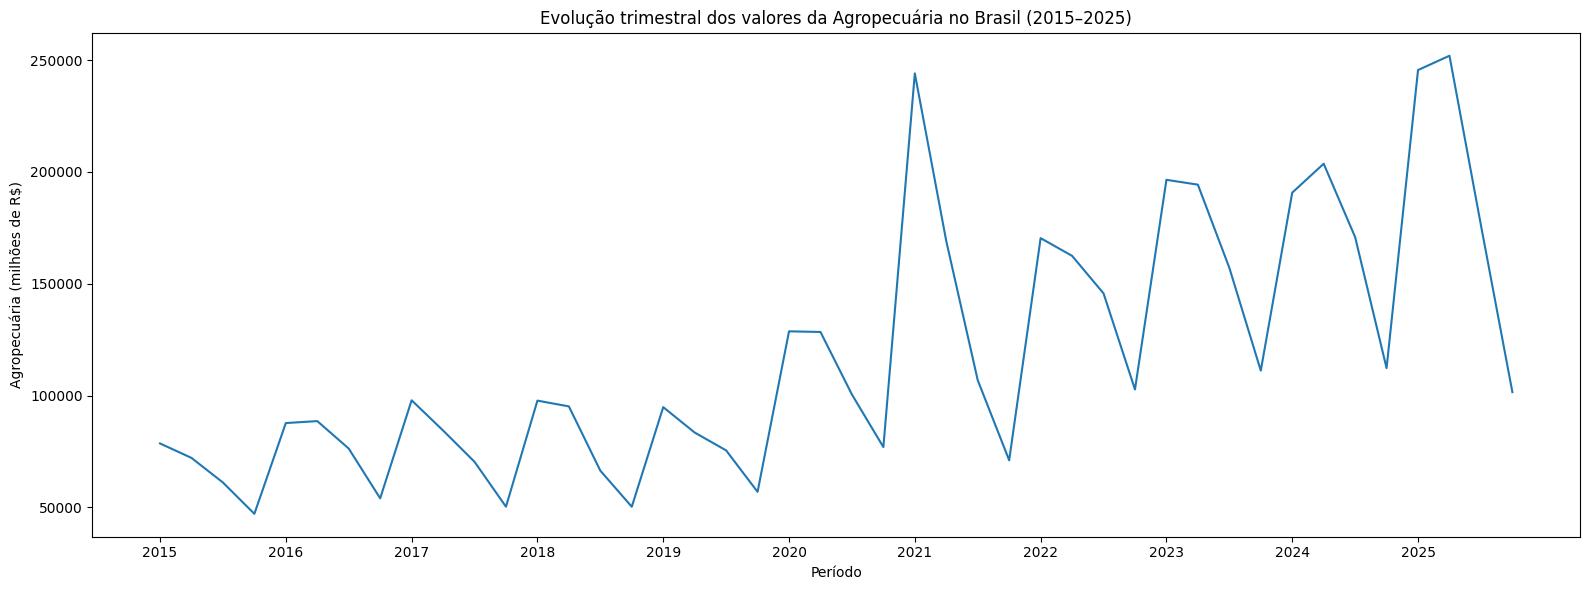

In [178]:
# Define o tamanho da figura: 16 de largura e 6 de altura
plt.figure(figsize=(16, 6))

# Cria o gráfico de linha, utilizando o período no eixo X e os valores da Agropecuária no eixo Y
plt.plot(dados["Periodo"], dados["Agropecuaria"])

# Adiciona um título ao gráfico
plt.title("Evolução trimestral dos valores da Agropecuária no Brasil (2015–2025)")

# Define o nome do eixo X
plt.xlabel("Período")

# Define o nome do eixo Y e informa a unidade dos dados
plt.ylabel("Agropecuária (milhões de R$)")

# Seleciona uma posição a cada quatro observações, correspondendo ao início de cada ano
posicoes_anos = range(0, len(dados), 4)

# Utiliza os anos correspondentes como rótulos do eixo X
rotulos_anos = dados["Ano"].iloc[::4]

# Exibe apenas um rótulo por ano no eixo X
plt.xticks(posicoes_anos, rotulos_anos)

# Ajusta automaticamente os espaços do gráfico para evitar sobreposição dos elementos
plt.tight_layout()

# Exibe o gráfico
plt.show()

#### Observação inicial da série

A visualização da série trimestral evidencia oscilações recorrentes nos valores da Agropecuária ao longo do período analisado, com movimentos sucessivos de elevação e redução.

A identificação desse comportamento levanta a necessidade de investigar se as variações observadas apresentam algum padrão associado aos diferentes trimestres do ano.

#### Investigação das variações entre os trimestres

A visualização da série temporal indicou a presença de oscilações recorrentes nos valores da Agropecuária. Para investigar se esse comportamento pode estar relacionado aos diferentes períodos do ano, os dados serão observados de acordo com o trimestre correspondente.

Essa análise permitirá verificar se determinados trimestres apresentam, de forma recorrente, valores mais elevados ou reduzidos ao longo dos anos analisados.

In [179]:
# Seleciona apenas o ano, o trimestre e o valor da Agropecuária
dados[["Ano", "Trimestre", "Agropecuaria"]].head(12)

,Ano,Trimestre,Agropecuaria
0,2015,1,78592
1,2015,2,72124
2,2015,3,61128
3,2015,4,47123
4,2016,1,87710
5,2016,2,88587
6,2016,3,76306
7,2016,4,54051
8,2017,1,97889
9,2017,2,84391


#### Agrupamento dos dados por trimestre

Para comparar o comportamento da Agropecuária entre os diferentes trimestres, foi utilizado o método `groupby()` da biblioteca Pandas.

Esse método permite agrupar as observações de acordo com uma determinada característica. Neste caso, os dados foram agrupados pela variável `Trimestre`, formando quatro grupos: todas as observações referentes ao 1º trimestre, ao 2º trimestre, ao 3º trimestre e ao 4º trimestre dos anos de 2015 a 2025.

Após o agrupamento, foi selecionada a variável `Agropecuaria` e aplicado o método `mean()`, responsável por calcular a média dos valores presentes em cada grupo.

Dessa forma, em vez de analisar individualmente os 44 valores trimestrais, é possível obter uma medida representativa para cada trimestre e realizar uma comparação inicial entre eles.

In [180]:
# Agrupa os dados de acordo com o trimestre e calcula a média dos valores da Agropecuária
dados.groupby("Trimestre")["Agropecuaria"].mean()

,Agropecuaria
Trimestre,
1,148434.181818
2,139428.636364
3,109729.181818
4,75859.272727


In [181]:
dados.groupby("Trimestre")

groupby("Trimestre"): separa as 44 observações em 4 grupos de acordo com o trimestre.

["Agropecuaria"]: determina qual variável queremos analisar dentro desses grupos.

.mean(): calcula a média da Agropecuária para cada um dos quatro grupos.

#### Comparação das médias por trimestre

A comparação das médias dos valores da Agropecuária entre os quatro trimestres reforça o padrão inicialmente observado na série temporal. O 1º trimestre apresentou a maior média no período analisado, seguido pelo 2º e pelo 3º trimestre, enquanto o 4º trimestre apresentou a menor média.

Esse resultado indica a presença de diferenças recorrentes entre os trimestres. Entretanto, como a série abrange um período de onze anos e os valores estão expressos a preços correntes, essa comparação deve ser interpretada com cautela, pois as médias também podem ser influenciadas pela evolução dos valores ao longo do tempo.

#### Comparação dos trimestres ao longo dos anos

A comparação das médias indicou diferenças entre os valores da Agropecuária nos quatro trimestres. Entretanto, a utilização da média reúne observações de todo o período de 2015 a 2025 em um único valor para cada trimestre.

Para verificar se o comportamento identificado ocorre de forma recorrente ao longo da série, será realizada uma comparação dos quatro trimestres dentro de cada ano. Essa organização permite observar se as diferenças entre os trimestres se repetem ao longo do período analisado.

In [182]:
# Reorganiza os dados para que cada linha represente um ano
# e cada coluna represente um dos quatro trimestres
agro_por_trimestre = dados.pivot(
    index="Ano",
    columns="Trimestre",
    values="Agropecuaria"
)

# Exibe a tabela reorganizada
agro_por_trimestre

Trimestre,1,2,3,4
Ano,,,,
2015,78592,72124,61128,47123
2016,87710,88587,76306,54051
2017,97889,84391,70396,50296
2018,97742,95160,66423,50287
2019,94821,83473,75480,56940
2020,128729,128444,100483,76965
2021,244068,169064,106886,71067
2022,170408,162485,145705,102745
2023,196486,194327,157149,111162


### 5.3 Evolução do PIB brasileiro

Após a análise inicial do comportamento da Agropecuária, será observada a evolução do Produto Interno Bruto (PIB) brasileiro ao longo do mesmo período.

A análise utiliza os valores trimestrais do PIB a preços de mercado, permitindo observar sua trajetória entre 2015 e 2025. Posteriormente, essas informações serão utilizadas em conjunto com os dados da Agropecuária para analisar a participação do setor na economia brasileira.

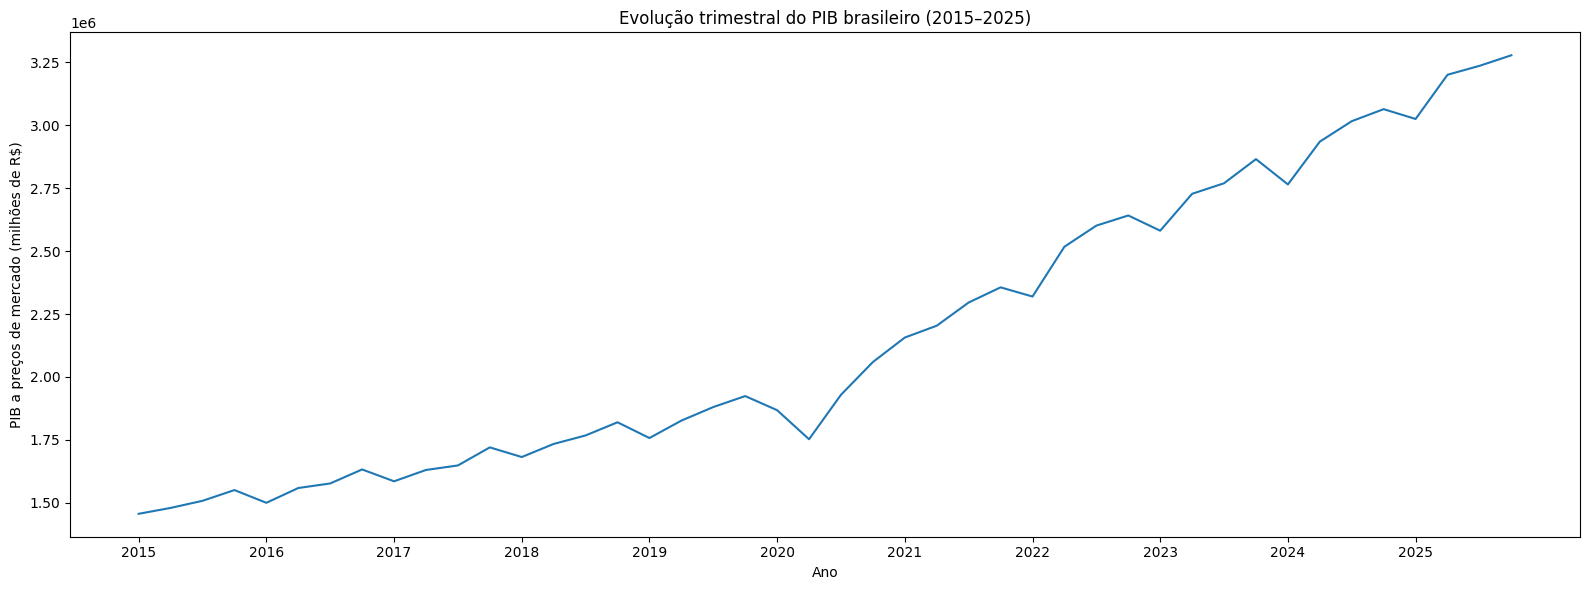

In [183]:
# Define o tamanho da figura: 16 de largura e 6 de altura
plt.figure(figsize=(16, 6))

# Cria o gráfico de linha com o período no eixo X e os valores do PIB no eixo Y
plt.plot(dados["Periodo"], dados["PIB"])

# Adiciona um título ao gráfico
plt.title("Evolução trimestral do PIB brasileiro (2015–2025)")

# Define o nome do eixo X
plt.xlabel("Ano")

# Define o nome do eixo Y e informa a unidade dos dados
plt.ylabel("PIB a preços de mercado (milhões de R$)")

# Seleciona uma posição a cada quatro observações,
# correspondendo ao início de cada ano
posicoes_anos = range(0, len(dados), 4)

# Seleciona um ano a cada quatro observações
# para utilizar como rótulo no eixo X
rotulos_anos = dados["Ano"].iloc[::4]

# Exibe apenas um rótulo por ano no eixo X,
# evitando a sobreposição dos 44 períodos trimestrais
plt.xticks(posicoes_anos, rotulos_anos)

# Ajusta automaticamente os espaços do gráfico
# para evitar que títulos e rótulos sejam cortados
plt.tight_layout()

# Exibe o gráfico
plt.show()

### 5.4 Participação da Agropecuária no PIB brasileiro

Após analisar separadamente a evolução dos valores da Agropecuária e do PIB brasileiro, será investigada a participação da Agropecuária no valor total do PIB em cada trimestre.

Essa medida permite observar quanto o valor da Agropecuária representa, proporcionalmente, em relação ao PIB brasileiro ao longo do período de 2015 a 2025.

A utilização de uma medida percentual também permite comparar essa participação entre os diferentes períodos da série, independentemente da diferença de magnitude entre os valores absolutos da Agropecuária e do PIB.

#### Cálculo da participação percentual

A participação da Agropecuária no PIB foi calculada por meio da razão entre o valor da Agropecuária e o valor do PIB correspondente ao mesmo trimestre. Em seguida, o resultado foi multiplicado por 100 para expressar essa relação em termos percentuais.

Dessa forma, foi criada uma nova variável denominada `Participacao_Agro_PIB`, que representa a participação percentual da Agropecuária no PIB brasileiro em cada uma das 44 observações trimestrais.

O cálculo utilizado pode ser representado pela seguinte expressão:

**Participação da Agropecuária no PIB (%) = (Agropecuária / PIB) × 100**

In [184]:
# Calcula quanto o valor da Agropecuária representa do PIB em cada trimestre
# A divisão gera uma proporção e a multiplicação por 100 transforma o resultado em porcentagem
dados["Participacao_Agro_PIB"] = (dados["Agropecuaria"] / dados["PIB"]) * 100

# Visualiza as primeiras observações com a nova variável
dados.head()

,Periodo,Agropecuaria,PIB,Ano,Trimestre,Participacao_Agro_PIB
0,1º trimestre 2015,78592,1456659,2015,1,5.395360
1,2º trimestre 2015,72124,1479970,2015,2,4.873342
2,3º trimestre 2015,61128,1508228,2015,3,4.052968
3,4º trimestre 2015,47123,1550930,2015,4,3.038371
4,1º trimestre 2016,87710,1500299,2016,1,5.846168


In [185]:
# Calcula estatísticas descritivas da participação da Agropecuária no PIB
dados["Participacao_Agro_PIB"].describe()

,Participacao_Agro_PIB
count,44.000000
mean,5.351105
std,1.792287
min,2.762866
25%,3.887149
50%,5.395207
75%,6.563433
max,11.316891


In [186]:
# Identifica o índice da observação que possui a maior participação
dados["Participacao_Agro_PIB"].idxmax()

24

In [187]:
# Localiza a linha correspondente ao maior valor de participação da Agropecuária no PIB
dados.loc[24]

,24
Periodo,1º trimestre 2021
Agropecuaria,244068
PIB,2156670
Ano,2021
Trimestre,1
Participacao_Agro_PIB,11.316891


#### Identificação da maior participação no período

A partir das estatísticas descritivas, foi identificado que a maior participação da Agropecuária no PIB durante o período analisado foi de aproximadamente 11,32%.

Para localizar a observação correspondente, utilizou-se o método idxmax(), que retorna o índice em que ocorre o maior valor de uma variável. Em seguida, o método loc[] foi utilizado para acessar os dados completos dessa observação.

A maior participação foi registrada no primeiro trimestre de 2021, quando a Agropecuária apresentou valor de R\$ 244.068 milhões diante de um PIB de R\$ 2.156.670 milhões, correspondendo a aproximadamente 11,32% do PIB naquele trimestre.

In [188]:
# Identifica o índice da observação com a menor participação da Agropecuária no PIB
indice_minimo = dados["Participacao_Agro_PIB"].idxmin()

# Localiza e exibe todas as informações correspondentes a essa observação
dados.loc[indice_minimo]

,15
Periodo,4º trimestre 2018
Agropecuaria,50287
PIB,1820103
Ano,2018
Trimestre,4
Participacao_Agro_PIB,2.762866


#### Evolução da participação da Agropecuária no PIB

Após o cálculo da participação percentual, será analisada sua evolução ao longo do período de 2015 a 2025.

A representação gráfica permite observar como a participação da Agropecuária no PIB variou entre os 44 trimestres analisados, complementando as estatísticas descritivas e permitindo visualizar a trajetória entre os valores mínimos e máximos identificados.

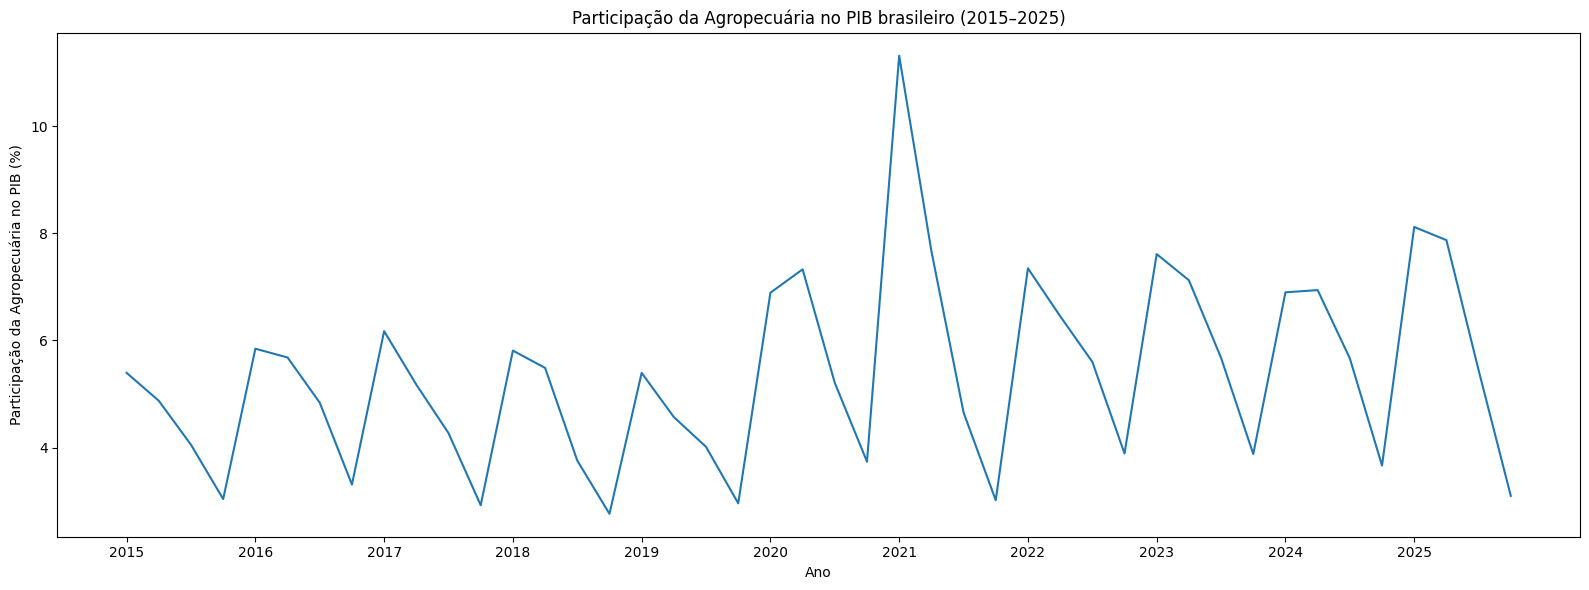

In [189]:
# Define o tamanho da figura
plt.figure(figsize=(16, 6))

# Cria o gráfico com os períodos no eixo X e a participação percentual no eixo Y
plt.plot(dados["Periodo"], dados["Participacao_Agro_PIB"])

# Adiciona o título do gráfico
plt.title("Participação da Agropecuária no PIB brasileiro (2015–2025)")

# Define o título do eixo X
plt.xlabel("Ano")

# Define o título do eixo Y e informa que os valores estão em porcentagem
plt.ylabel("Participação da Agropecuária no PIB (%)")

# Seleciona uma posição a cada quatro observações para representar os anos
posicoes_anos = range(0, len(dados), 4)

# Seleciona um ano a cada quatro observações
rotulos_anos = dados["Ano"].iloc[::4]

# Exibe apenas um rótulo por ano no eixo X
plt.xticks(posicoes_anos, rotulos_anos)

# Ajusta os espaços do gráfico
plt.tight_layout()

# Exibe o gráfico
plt.show()

### 5.5 Comparação dos valores da Agropecuária por ano

Após analisar a evolução trimestral da Agropecuária e sua participação no PIB brasileiro, será realizada uma comparação dos valores da Agropecuária entre os anos de 2015 e 2025.

Como a base utilizada apresenta quatro observações trimestrais para cada ano, inicialmente os valores dos quatro trimestres serão agrupados e somados, obtendo-se um valor anual para a Agropecuária.

A partir desses resultados, os anos serão ordenados de acordo com os valores obtidos, permitindo construir um ranking e identificar quais anos apresentaram os maiores e menores valores da Agropecuária no período analisado.

É importante considerar que os dados estão expressos a preços correntes. Portanto, o ranking representa uma comparação dos valores nominais registrados em cada ano e não deve ser interpretado diretamente como um ranking de crescimento real da Agropecuária.

In [190]:
# Agrupa as observações pelo ano e soma os quatro valores trimestrais da Agropecuária
agro_anual = dados.groupby("Ano")["Agropecuaria"].sum()

# Exibe os valores anuais obtidos
agro_anual

,Agropecuaria
Ano,
2015,258967
2016,306654
2017,302972
2018,309612
2019,310714
2020,434621
2021,591085
2022,581343
2023,659124
